# Polarized fixed-amplitude closure

This notebook compares one generated polarized ROOT file directly with one polarized fit ROOT file.

Change the two filenames in the next cell, run the notebook, and inspect the Argand plot. Generated amplitudes are stars and fitted amplitudes are circles. No phase rotation or reference-frame transformation is applied: both points are plotted in the gauge imposed by generation and minimization.


In [5]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ROOT
from matplotlib.lines import Line2D

PROJECT_DIR = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "InputFiles").is_dir() and (path / "OutputFiles").is_dir()
)

# Normally these are the only two lines that need changing.
TRUTH_FILE = Path("InputFiles/Generated/fixed_both_moments.root")
FIT_FILE = Path("OutputFiles/fixed_both_fit.root")

TRUTH_TREE = "genMoments"
FIT_TREE = "fitResults"

if not TRUTH_FILE.is_absolute():
    TRUTH_FILE = PROJECT_DIR / TRUTH_FILE
if not FIT_FILE.is_absolute():
    FIT_FILE = PROJECT_DIR / FIT_FILE

CASE_NAME = FIT_FILE.stem
OUTPUT_DIR = (
    PROJECT_DIR / "AnalysisScripts" / "outputs"
    / "polarized_fixed_amp_analysis" / CASE_NAME
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 24,
    "axes.titlesize": 28,
    "axes.labelsize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 14,
    "lines.linewidth": 2.5,
    "axes.linewidth": 2.0,
    "savefig.dpi": 300,
})

print("Generated data:", TRUTH_FILE)
print("Polarized fit:", FIT_FILE)
print("Plots:", OUTPUT_DIR)


Generated data: /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter-refactored/InputFiles/Generated/fixed_both_moments.root
Polarized fit: /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter-refactored/OutputFiles/fixed_both_fit.root
Plots: /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter-refactored/AnalysisScripts/outputs/polarized_fixed_amp_analysis/fixed_both_fit


In [6]:
polarized_magnitude = re.compile(
    r"^[ab]_[TL]_\d+_m?\d+_(?:1|m1)$"
)

truth_root = ROOT.TFile.Open(str(TRUTH_FILE), "READ")
fit_root = ROOT.TFile.Open(str(FIT_FILE), "READ")
if not truth_root or truth_root.IsZombie():
    raise OSError(f"Could not open {TRUTH_FILE}")
if not fit_root or fit_root.IsZombie():
    raise OSError(f"Could not open {FIT_FILE}")

truth_tree = truth_root.Get(TRUTH_TREE)
fit_tree = fit_root.Get(FIT_TREE)
if not truth_tree:
    raise KeyError(f"Tree {TRUTH_TREE!r} not found in {TRUTH_FILE}")
if not fit_tree:
    raise KeyError(f"Tree {FIT_TREE!r} not found in {FIT_FILE}")

truth_branches = {str(branch.GetName()) for branch in truth_tree.GetListOfBranches()}
fit_branches = {str(branch.GetName()) for branch in fit_tree.GetListOfBranches()}
truth_root.Close()
fit_root.Close()

truth_magnitudes = {
    name for name in truth_branches if polarized_magnitude.fullmatch(name)
}
fit_magnitudes = {
    name for name in fit_branches if polarized_magnitude.fullmatch(name)
}
common_amplitudes = sorted(truth_magnitudes & fit_magnitudes)
if not common_amplitudes:
    raise RuntimeError("No common polarized amplitude branches were found")

truth_columns = []
fit_columns = []
for name in common_amplitudes:
    phase_name = ("aphi" if name.startswith("a_") else "bphi") + name[1:]
    if phase_name not in truth_branches:
        raise KeyError(f"Missing generated phase branch {phase_name}")
    if phase_name not in fit_branches:
        raise KeyError(f"Missing fitted phase branch {phase_name}")
    truth_columns.extend([name, phase_name])
    fit_columns.extend([name, phase_name])

truth_arrays = ROOT.RDataFrame(TRUTH_TREE, str(TRUTH_FILE)).AsNumpy(columns=truth_columns)
if not truth_arrays or len(next(iter(truth_arrays.values()))) == 0:
    raise RuntimeError(f"No entries in {TRUTH_FILE}:{TRUTH_TREE}")
truth = {name: values[0] for name, values in truth_arrays.items()}

status_columns = [
    name for name in ("fit_ok", "status", "chi2", "edm", "log_val")
    if name in fit_branches
]
fit_columns = list(dict.fromkeys(status_columns + fit_columns))
fit_arrays = ROOT.RDataFrame(FIT_TREE, str(FIT_FILE)).AsNumpy(columns=fit_columns)
if "chi2" not in fit_arrays:
    raise RuntimeError("The fit tree needs a chi2 branch")

usable = np.isfinite(fit_arrays["chi2"])
if "fit_ok" in fit_arrays:
    usable &= fit_arrays["fit_ok"] != 0
    if not np.any(usable):
        raise RuntimeError("No accepted fit entry was found")
entries = np.flatnonzero(usable)
if len(entries) == 0:
    raise RuntimeError("No finite fit entry was found")
best_entry = entries[np.argmin(fit_arrays["chi2"][entries])]
fit = {name: values[best_entry] for name, values in fit_arrays.items()}

truth_amplitudes = {}
fit_amplitudes = {}
for name in common_amplitudes:
    phase_name = ("aphi" if name.startswith("a_") else "bphi") + name[1:]
    truth_amplitudes[name] = (
        float(truth[name]) * np.exp(1j * float(truth[phase_name]))
    )
    fit_amplitudes[name] = (
        float(fit[name]) * np.exp(1j * float(fit[phase_name]))
    )

print("Best fit entry:", best_entry)
print("Fit status:", {name: fit[name] for name in status_columns})
print("Compared polarized amplitudes:", len(common_amplitudes))

Best fit entry: 0
Fit status: {'fit_ok': np.True_, 'status': np.int32(0), 'chi2': np.float64(0.029406860070668114), 'edm': np.float64(7.830429012101752e-10), 'log_val': np.float64(-9.395824209252813)}
Compared polarized amplitudes: 28


In [7]:
print(
    f"{'amplitude':<18} {'truth Re':>11} {'truth Im':>11} "
    f"{'fit Re':>11} {'fit Im':>11} {'|fit-truth|':>13}"
)
print("-" * 80)

complex_residuals = []
for name in common_amplitudes:
    generated = truth_amplitudes[name]
    fitted = fit_amplitudes[name]
    residual = abs(fitted - generated)
    complex_residuals.append(residual)
    print(
        f"{name:<18} {generated.real:11.6f} {generated.imag:11.6f} "
        f"{fitted.real:11.6f} {fitted.imag:11.6f} {residual:13.6g}"
    )

print("\nMaximum complex-amplitude residual:", max(complex_residuals))


amplitude             truth Re    truth Im      fit Re      fit Im   |fit-truth|
--------------------------------------------------------------------------------
a_L_0_0_1             0.030139    0.017794   -0.000000   -0.000000         0.035
a_L_0_0_m1           -0.011663   -0.038262   -0.038965    0.000974     0.0478002
a_L_1_0_1            -0.018667    0.029607   -0.019604    0.029849   0.000968103
a_L_1_0_m1            0.038586   -0.010541    0.001404   -0.018150     0.0379528
a_L_1_1_1            -0.040557   -0.037150   -0.040101   -0.038671    0.00158698
a_L_1_1_m1            0.024116    0.006588    0.018529   -0.028537     0.0355666
a_T_0_0_1            -0.016036    0.052610   -0.016801   -0.000000     0.0526157
a_T_0_0_m1            0.021528   -0.012710   -0.005932   -0.057129     0.0522217
a_T_1_0_1            -0.001606   -0.054977   -0.001451   -0.056359    0.00139094
a_T_1_0_m1            0.012076    0.021890    0.000010    0.000026     0.0249718
a_T_1_1_1             0.9789

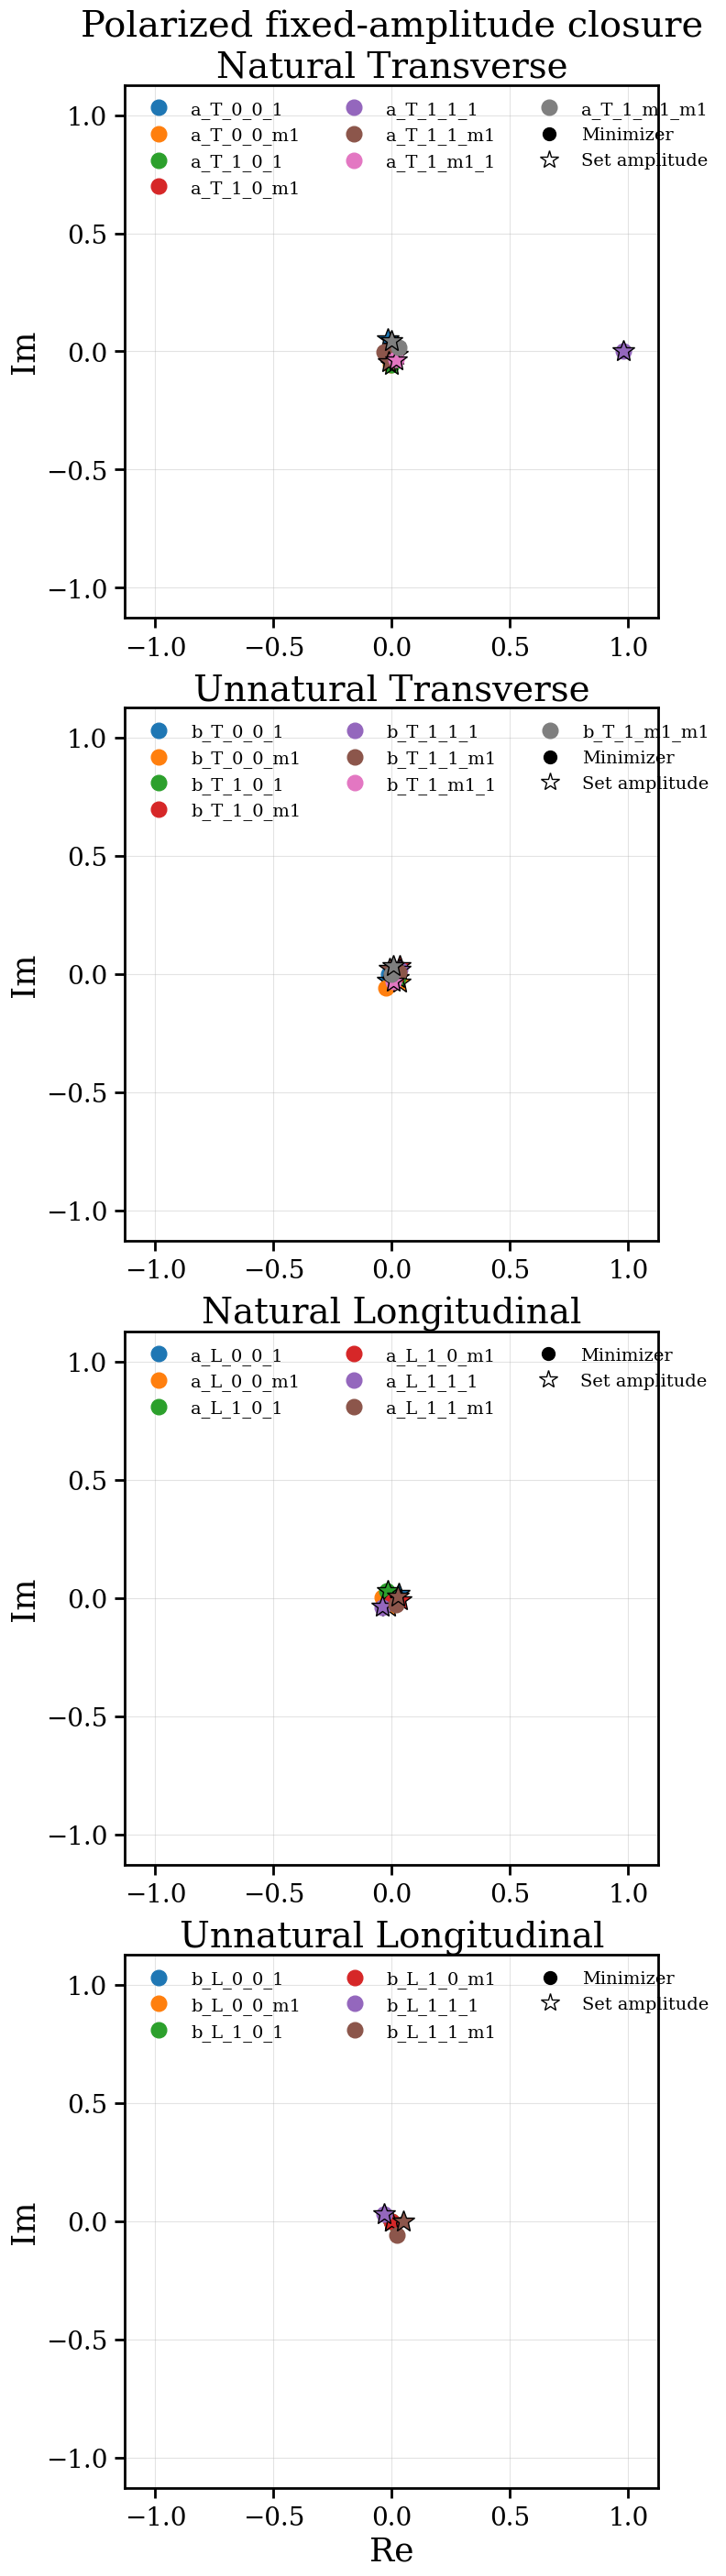

Wrote plot to /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter-refactored/AnalysisScripts/outputs/polarized_fixed_amp_analysis/fixed_both_fit


In [8]:
group_definitions = [
    (("a", "T"), "Natural Transverse"),
    (("b", "T"), "Unnatural Transverse"),
    (("a", "L"), "Natural Longitudinal"),
    (("b", "L"), "Unnatural Longitudinal"),
]
present_groups = []
for group, title in group_definitions:
    if any(tuple(name.split("_")[:2]) == group for name in common_amplitudes):
        present_groups.append((group, title))

figure, axes = plt.subplots(
    len(present_groups), 1,
    figsize=(11, 7 * len(present_groups)),
    constrained_layout=True,
    squeeze=False,
)
axes = axes[:, 0]
extent = 0.0

for axis, (group, title) in zip(axes, present_groups):
    selected = [
        name for name in common_amplitudes
        if tuple(name.split("_")[:2]) == group
    ]
    for index, name in enumerate(selected):
        color = f"C{index % 10}"
        generated = truth_amplitudes[name]
        fitted = fit_amplitudes[name]

        axis.plot(
            fitted.real, fitted.imag, "o",
            color=color, markersize=12, label=name,
        )
        axis.plot(
            generated.real, generated.imag, "*",
            color=color, markeredgecolor="black",
            markersize=18, linestyle="none",
        )
        extent = max(
            extent,
            abs(generated.real), abs(generated.imag),
            abs(fitted.real), abs(fitted.imag),
        )

    axis.set_title(title)
    axis.set_ylabel("Im")
    axis.grid(alpha=0.35)
    axis.set_aspect("equal", adjustable="box")
    axis.tick_params(axis="both", which="major", width=2, length=8, pad=6)
    for spine in axis.spines.values():
        spine.set_linewidth(2)

    handles, labels = axis.get_legend_handles_labels()
    handles.extend([
        Line2D([0], [0], marker="o", color="black", linestyle="none",
               markersize=10, label="Minimizer"),
        Line2D([0], [0], marker="*", color="white", markeredgecolor="black",
               markersize=15, linestyle="none", label="Set amplitude"),
    ])
    axis.legend(handles=handles, frameon=False, ncol=3, loc="upper left")

limit = 1.15 * max(extent, 0.1)
for axis in axes:
    axis.set_xlim(-limit, limit)
    axis.set_ylim(-limit, limit)
axes[-1].set_xlabel("Re")

figure.suptitle("Polarized fixed-amplitude closure")
figure.savefig(
    OUTPUT_DIR / f"{CASE_NAME}_argand.pdf",
    dpi=600, bbox_inches="tight", transparent=True,
)
plt.show()

print("Wrote plot to", OUTPUT_DIR)
